In [1]:
# out 2, loss = 1 - cos()
# vqc_mlp_pennylane_pipeline_FIXED_VQC.py

import os
import time
import numpy as np
from numpy.polynomial.hermite import hermgauss
import pennylane as qml
import pennylane.numpy as pnp
import matplotlib.pyplot as plt
from itertools import combinations

# -----------------------
# === User parameters ===
# -----------------------
n_qubits = 8
n_enc, n_dec = 1, 1
phi_train_samples = 100
n_phi = 50
maxiter = 3000
seed = 42
np.random.seed(seed)

# output path
path = f"VQ-CNNI_fixedParam/{n_qubits}/vqc_{n_enc}_{n_dec}/softsign"
os.makedirs(path, exist_ok=True)

# -----------------------
# === Training grid ===
# -----------------------
phi_train = np.linspace(-np.pi, np.pi, phi_train_samples)
weights = np.ones_like(phi_train) / len(phi_train)

delta = 2 * np.pi / (phi_train_samples)  # 让点数恰好为 phi_train_samples
phi_trues = np.linspace(-np.pi, np.pi - delta, n_phi)

# -----------------------
# === index -> m mapping ===
# -----------------------
dim = 2 ** n_qubits
index_to_m = np.zeros(dim, dtype=int)
for idx in range(dim):
    bitstr = format(idx, f"0{n_qubits}b")
    index_to_m[idx] = bitstr.count('0') - bitstr.count('1')

unique_m = np.sort(np.unique(index_to_m))

# -----------------------
# === PennyLane device & QNodes ===
# -----------------------
dev = qml.device("default.qubit", wires=n_qubits)

# convenience rzz implementation to match earlier qiskit-like pattern
def rzz_qiskit(chi, i, j):
    qml.CNOT(wires=[i, j])
    qml.RZ(chi, wires=j)
    qml.CNOT(wires=[i, j])

# We'll create QNodes that take (phi, flat_params) where flat_params encodes
# quantum parameters only (theta_flat and curly_flat). MLP params live in same
# big vector x but will be ignored by circuit QNodes (we'll unpack).
@qml.qnode(dev, interface="autograd")
def circuit_state(phi, q_params):
    """Return pure state vector for given phi and quantum parameters q_params."""
    # q_params is a flat array containing theta_flat (3*n_enc) then curly_flat (3*n_dec)
    # unpack
    t_len = 3 * n_enc
    c_len = 3 * n_dec
    theta_flat = q_params[:t_len] if t_len > 0 else pnp.array([])
    curly_flat = q_params[t_len : t_len + c_len] if c_len > 0 else pnp.array([])

    # input rotation
    for q in range(n_qubits):
        qml.RY(pnp.pi / 2, wires=q)

    # encoding layers
    for layer_idx in range(n_enc):
        t1 = theta_flat[layer_idx * 3 + 0]
        t2 = theta_flat[layer_idx * 3 + 1]
        t3 = theta_flat[layer_idx * 3 + 2]
        # twisting_z
        for i, j in combinations(range(n_qubits), 2):
            rzz_qiskit(t1 / 2.0, i, j)
        # twisting_x
        for q in range(n_qubits):
            qml.Hadamard(wires=q)
        for i, j in combinations(range(n_qubits), 2):
            rzz_qiskit(t2 / 2.0, i, j)
        for q in range(n_qubits):
            qml.Hadamard(wires=q)
        # collective rx
        for q in range(n_qubits):
            qml.RX(t3, wires=q)

    # phase encoding
    for q in range(n_qubits):
        qml.RZ(phi, wires=q)

    # decoding layers
    for layer_idx in range(n_dec):
        v1 = curly_flat[layer_idx * 3 + 0]
        v2 = curly_flat[layer_idx * 3 + 1]
        v3 = curly_flat[layer_idx * 3 + 2]
        for q in range(n_qubits):
            qml.RX(v3, wires=q)
        for q in range(n_qubits):
            qml.Hadamard(wires=q)
        for i, j in combinations(range(n_qubits), 2):
            rzz_qiskit(v2 / 2.0, i, j)
        for q in range(n_qubits):
            qml.Hadamard(wires=q)
        for i, j in combinations(range(n_qubits), 2):
            rzz_qiskit(v1 / 2.0, i, j)

    for q in range(n_qubits):
        qml.RX(pnp.pi / 2, wires=q)

    return qml.state()
    

# -----------------------
# === Quantum circuit (fixed params) ===
# -----------------------
@qml.qnode(dev, interface="autograd")
def circuit_probs(phi, q_params):
    t_len = 3 * n_enc
    theta = q_params[:t_len]
    curly = q_params[t_len:]

    for q in range(n_qubits):
        qml.RY(pnp.pi / 2, wires=q)

    for l in range(n_enc):
        t1, t2, t3 = theta[3*l:3*l+3]
        for i, j in combinations(range(n_qubits), 2):
            rzz_qiskit(t1 / 2, i, j)
        for q in range(n_qubits):
            qml.Hadamard(wires=q)
        for i, j in combinations(range(n_qubits), 2):
            rzz_qiskit(t2 / 2, i, j)
        for q in range(n_qubits):
            qml.Hadamard(wires=q)
        for q in range(n_qubits):
            qml.RX(t3, wires=q)

    for q in range(n_qubits):
        qml.RZ(phi, wires=q)

    for l in range(n_dec):
        v1, v2, v3 = curly[3*l:3*l+3]
        for q in range(n_qubits):
            qml.RX(v3, wires=q)
        for q in range(n_qubits):
            qml.Hadamard(wires=q)
        for i, j in combinations(range(n_qubits), 2):
            rzz_qiskit(v2 / 2, i, j)
        for q in range(n_qubits):
            qml.Hadamard(wires=q)
        for i, j in combinations(range(n_qubits), 2):
            rzz_qiskit(v1 / 2, i, j)

    for q in range(n_qubits):
        qml.RX(pnp.pi / 2, wires=q)

    return qml.probs(wires=range(n_qubits))

def softsign(x):
    return x/(1+pnp.abs(x))
    
# -----------------------
# === MLP estimator ===
# -----------------------
class MLP:
    def __init__(self, dim_in, hidden=128, seed=0):
        r = np.random.RandomState(seed)
        self.W1 = pnp.array(r.randn(hidden, dim_in)*0.1, requires_grad=True)
        self.b1 = pnp.zeros(hidden, requires_grad=True)
        self.W2 = pnp.array(r.randn(hidden//2, hidden)*0.1, requires_grad=True)
        self.b2 = pnp.zeros(hidden//2, requires_grad=True)
        self.W3 = pnp.array(r.randn(2, hidden//2)*0.1, requires_grad=True)
        self.b3 = pnp.zeros(2, requires_grad=True)

    def __call__(self, p_m):
        h1 = softsign(self.W1 @ p_m + self.b1)
        h2 = softsign(self.W2 @ h1 + self.b2)
        out = self.W3 @ h2 + self.b3
        return out / (pnp.linalg.norm(out) + 1e-6)

    def params(self):
        return [self.W1, self.b1, self.W2, self.b2, self.W3, self.b3]

net = MLP(len(unique_m), seed=seed)

# -----------------------
# === Fixed VQC parameters ===
# -----------------------
q_params_fixed = pnp.array([3.58809973e-01, -4.38641827e-02, 5.88536701e-01, 5.08765401e-06,  1.68364862e-01, 9.57706065e-02], requires_grad=False)

# -----------------------
# === helpers ===
# -----------------------
def probs_to_p_m(probs):
    return pnp.array([pnp.sum(probs[index_to_m == m]) for m in unique_m])

def pack_mlp(params):
    return pnp.concatenate([pnp.ravel(p) for p in params])

def unpack_mlp(x):
    shapes = [p.shape for p in net.params()]
    sizes = [np.prod(s) for s in shapes]
    out, k = [], 0
    for s, sh in zip(sizes, shapes):
        out.append(x[k:k+s].reshape(sh))
        k += s
    return out

# -----------------------
# === Loss (MLP only) ===
# -----------------------
def objective(x):
    W1, b1, W2, b2, W3, b3 = unpack_mlp(x)
    net.W1, net.b1, net.W2, net.b2, net.W3, net.b3 = W1, b1, W2, b2, W3, b3

    loss = 0.0
    for phi, w in zip(phi_train, weights):
        probs = circuit_probs(phi, q_params_fixed)
        p_m = probs_to_p_m(probs)
        v = net(p_m)
        phi_hat = pnp.arctan2(v[0], v[1])
        loss += w * (1 - pnp.cos(phi - phi_hat))
    return loss


# -----------------------
# === Training ===
# -----------------------
x = pnp.array(pack_mlp(net.params()), requires_grad=True)
opt = qml.AdamOptimizer(stepsize=0.02)
mse_history = []

best_loss = np.inf
best_x = None
best_it = -1

patience = 100              # 连续50次不提升就停止
no_improve_count = 0
min_iters = 500
print("Starting training...")
t0 = time.time()

for it in range(1, maxiter + 1):
    x, loss_val = opt.step_and_cost(objective, x)
    loss_val_f = float(loss_val)
    mse_history.append(loss_val_f)

    # ---- save best ----
    if loss_val_f < best_loss:
        best_loss = loss_val_f
        best_x = pnp.array(x, requires_grad=False)  # deep copy
        best_it = it
        no_improve_count = 0   # 有提升，清零
    else:
        no_improve_count += 1  # 没提升，计数+1

    if it % 5 == 0 or it <= 5:
        print(f"Iter {it:4d} | loss={loss_val_f:.6e} | best={best_loss:.6e} | no_improve={no_improve_count}")

    # ---- early stopping ----
    if it > min_iters and no_improve_count >= patience:
        print(f"\nEarly stopping at iter {it}, no improvement for {patience} iterations.")
        break

print(f"\nTraining finished in {time.time()-t0:.1f}s")
print(f"Best loss {best_loss:.6e} at iter {best_it}")

np.save(os.path.join(path, "mse_history.npy"), np.array(mse_history))

Starting training...
Iter    1 | loss=6.587464e-01 | best=6.587464e-01 | no_improve=0
Iter    2 | loss=6.198007e-01 | best=6.198007e-01 | no_improve=0
Iter    3 | loss=5.251235e-01 | best=5.251235e-01 | no_improve=0
Iter    4 | loss=4.489484e-01 | best=4.489484e-01 | no_improve=0
Iter    5 | loss=4.049469e-01 | best=4.049469e-01 | no_improve=0
Iter   10 | loss=3.807767e-01 | best=3.751360e-01 | no_improve=1
Iter   15 | loss=3.855128e-01 | best=3.751360e-01 | no_improve=6
Iter   20 | loss=3.796522e-01 | best=3.751360e-01 | no_improve=11
Iter   25 | loss=3.737054e-01 | best=3.734410e-01 | no_improve=1
Iter   30 | loss=3.689631e-01 | best=3.689631e-01 | no_improve=0
Iter   35 | loss=3.665408e-01 | best=3.665408e-01 | no_improve=0
Iter   40 | loss=3.803469e-01 | best=3.665408e-01 | no_improve=5
Iter   45 | loss=3.734683e-01 | best=3.665408e-01 | no_improve=10
Iter   50 | loss=3.687794e-01 | best=3.665408e-01 | no_improve=15
Iter   55 | loss=3.695012e-01 | best=3.665408e-01 | no_improve=20


<>:70: SyntaxWarning: invalid escape sequence '\p'
<>:72: SyntaxWarning: invalid escape sequence '\p'
<>:70: SyntaxWarning: invalid escape sequence '\p'
<>:72: SyntaxWarning: invalid escape sequence '\p'
C:\Users\qingchuan.yang\AppData\Local\Temp\ipykernel_30748\189278212.py:70: SyntaxWarning: invalid escape sequence '\p'
  plt.xlabel("$\phi$")
C:\Users\qingchuan.yang\AppData\Local\Temp\ipykernel_30748\189278212.py:72: SyntaxWarning: invalid escape sequence '\p'
  plt.title(f"SWPE VS $\phi$")


Test MSE: 2.952959e-01


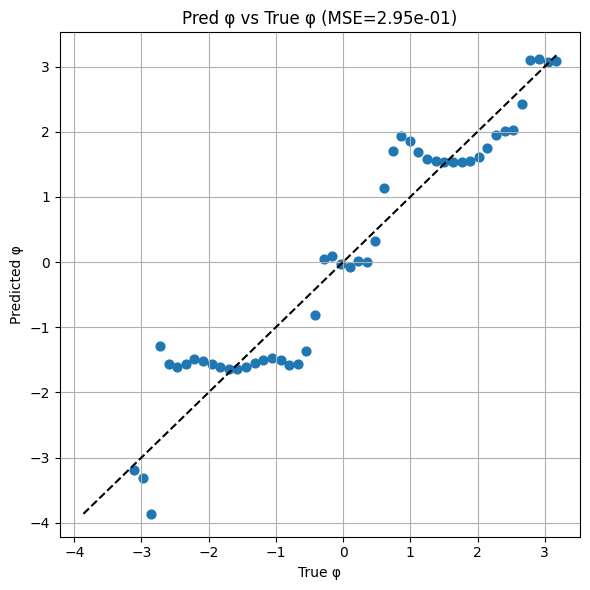

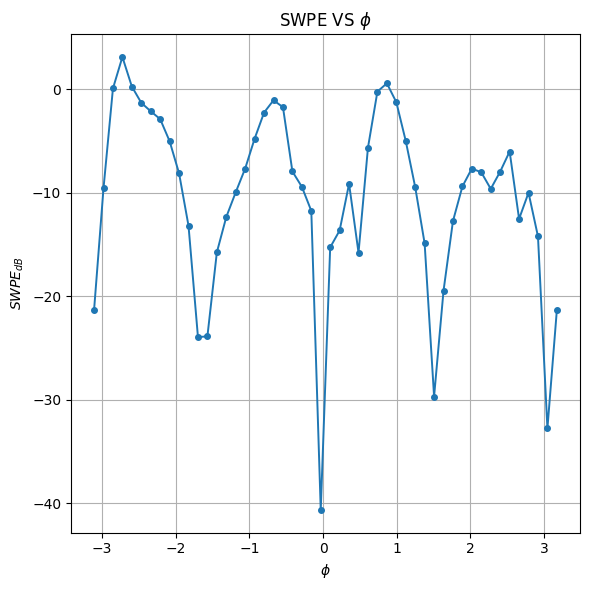

In [2]:
def adjust_phase_wrap(phi_true, phi_pred):
    """
    修正预测角度，使其在与真实角度相同的周期内（处理±π边界问题）。

    参数:
        phi_true: np.ndarray，真实相位（形状 [N]）
        phi_pred: np.ndarray，预测相位（形状 [N]）

    返回:
        phi_pred_adj: np.ndarray，修正后的预测相位
    """
    phi_pred_adj = phi_pred.copy()
    mask = np.abs(phi_true - phi_pred) > np.pi
    phi_pred_adj[mask] -= np.sign(phi_pred[mask]) * 2 * np.pi
    return phi_pred_adj

phi_trues = np.linspace(-np.pi + np.pi/phi_train_samples, np.pi + np.pi/phi_train_samples, n_phi)   
phi_list = phi_trues

# after training, unpack final parameters and set net params
net.W1, net.b1, net.W2, net.b2, net.W3, net.b3 = unpack_mlp(best_x)

# -----------------------
# === Evaluate on test phis: phi_pred vs phi_true ===
# -----------------------
index_to_m_pnp = pnp.array(index_to_m)

phi_preds = []
for phi in phi_list:
    probs = circuit_probs(phi, q_params_fixed)
    p_m = probs_to_p_m(probs)
    v = net(p_m)                      # shape (2,)
    phi_pred = pnp.arctan2(v[0], v[1])
    phi_preds.append(float(phi_pred))

phi_preds = np.array(phi_preds)

# 修正角度跳变（±π跨越）
phi_preds = adjust_phase_wrap(phi_trues, phi_preds)

mse_test = np.mean((phi_preds - phi_trues) ** 2)
print(f"Test MSE: {mse_test:.6e}")

# save phi predictions
np.save(os.path.join(path, "phi_preds.npy"), phi_preds)
np.save(os.path.join(path, "phi_trues.npy"), phi_trues)

# Plot phi_pred vs phi_true
plt.figure(figsize=(6,6))
plt.scatter(phi_trues, phi_preds, s=40)
lims = [min(phi_trues.min(), phi_preds.min()), max(phi_trues.max(), phi_preds.max())]
plt.plot(lims, lims, '--', color='k')
plt.xlabel("True φ")
plt.ylabel("Predicted φ")
plt.title(f"Pred φ vs True φ (MSE={mse_test:.2e})")
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(path, "phi_pred_vs_true.png"), dpi=200)
plt.show()

# squared wrapped phase error
SWPE = np.angle(np.exp(1j * (phi_preds - phi_trues))) ** 2
SWPE_dB = 10*np.log10(SWPE)
# Plot phi_pred vs phi_true
plt.figure(figsize=(6,6))
plt.plot(phi_trues, SWPE_dB, marker="o", markersize=4, linewidth=1.4)
# lims = [min(phi_trues.min(), phi_preds.min()), max(phi_trues.max(), phi_preds.max())]
# plt.plot(lims, lims, '--', color='k')
plt.xlabel("$\phi$")
plt.ylabel("$SWPE_{dB}$")
plt.title(f"SWPE VS $\phi$")
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(path, "SWPE.png"), dpi=200)
plt.show()


<>:104: SyntaxWarning: invalid escape sequence '\p'
<>:106: SyntaxWarning: invalid escape sequence '\p'
<>:104: SyntaxWarning: invalid escape sequence '\p'
<>:106: SyntaxWarning: invalid escape sequence '\p'
C:\Users\qingchuan.yang\AppData\Local\Temp\ipykernel_30748\3670832132.py:104: SyntaxWarning: invalid escape sequence '\p'
  plt.xlabel("$\phi$")
C:\Users\qingchuan.yang\AppData\Local\Temp\ipykernel_30748\3670832132.py:106: SyntaxWarning: invalid escape sequence '\p'
  plt.title(f"SWPE VS $\phi$")
C:\Users\qingchuan.yang\AppData\Local\Programs\Python\Python313\Lib\site-packages\pennylane\devices\device_api.py:193: PennyLaneDeprecationWarning: Setting shots on device is deprecated. Please use the `set_shots` transform on the respective QNode instead.
  warnings.warn(


Test MSE: 2.941175e-01


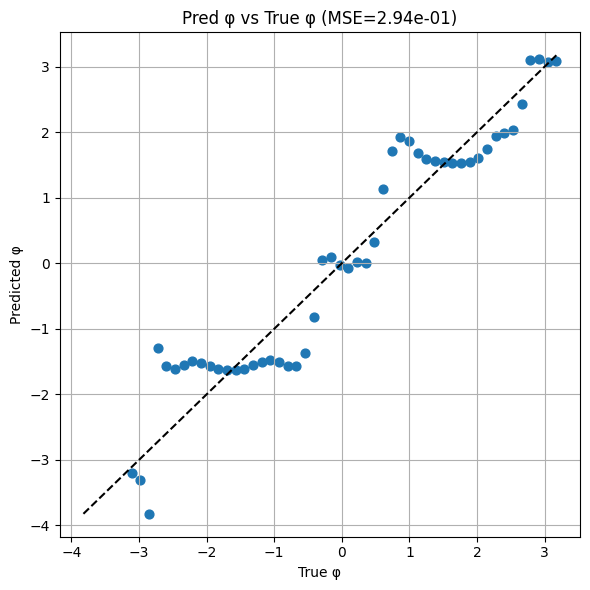

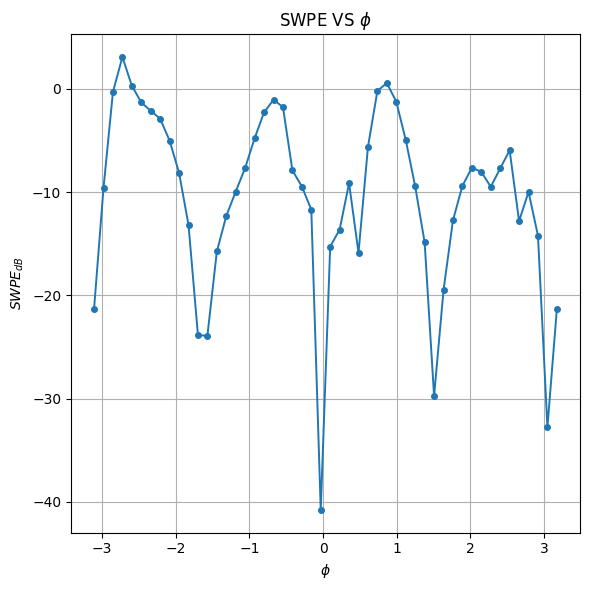

In [3]:
# -----------------------
# === PennyLane device & QNodes ===
# -----------------------
dev_shots = qml.device("default.qubit", wires=n_qubits, shots=10**6)

@qml.qnode(dev_shots, interface=None)
def circuit_probs_shots(phi, q_params):
    """Return computational-basis probabilities for given phi and quantum parameters q_params."""
    # build same circuit but return probs
    # unpack
    t_len = 3 * n_enc
    c_len = 3 * n_dec
    theta_flat = q_params[:t_len] if t_len > 0 else pnp.array([])
    curly_flat = q_params[t_len : t_len + c_len] if c_len > 0 else pnp.array([])

    # input rotation
    for q in range(n_qubits):
        qml.RY(pnp.pi / 2, wires=q)

    # encoding
    for layer_idx in range(n_enc):
        t1 = theta_flat[layer_idx * 3 + 0]
        t2 = theta_flat[layer_idx * 3 + 1]
        t3 = theta_flat[layer_idx * 3 + 2]
        for i, j in combinations(range(n_qubits), 2):
            rzz_qiskit(t1 / 2.0, i, j)
        for q in range(n_qubits):
            qml.Hadamard(wires=q)
        for i, j in combinations(range(n_qubits), 2):
            rzz_qiskit(t2 / 2.0, i, j)
        for q in range(n_qubits):
            qml.Hadamard(wires=q)
        for q in range(n_qubits):
            qml.RX(t3, wires=q)

    # phase
    for q in range(n_qubits):
        qml.RZ(phi, wires=q)

    # decoding
    for layer_idx in range(n_dec):
        v1 = curly_flat[layer_idx * 3 + 0]
        v2 = curly_flat[layer_idx * 3 + 1]
        v3 = curly_flat[layer_idx * 3 + 2]
        for q in range(n_qubits):
            qml.RX(v3, wires=q)
        for q in range(n_qubits):
            qml.Hadamard(wires=q)
        for i, j in combinations(range(n_qubits), 2):
            rzz_qiskit(v2 / 2.0, i, j)
        for q in range(n_qubits):
            qml.Hadamard(wires=q)
        for i, j in combinations(range(n_qubits), 2):
            rzz_qiskit(v1 / 2.0, i, j)

    for q in range(n_qubits):
        qml.RX(pnp.pi / 2, wires=q)

    return qml.probs(wires=list(range(n_qubits)))

phi_preds = []
for phi in phi_trues:
    probs = circuit_probs_shots(phi, q_params_fixed)
    p_m = probs_to_p_m(probs)
    v = net(p_m)                      # shape (2,)
    phi_pred = pnp.arctan2(v[0], v[1])
    phi_preds.append(float(qml.math.toarray(phi_pred)))

phi_preds = np.array(phi_preds)

# 修正角度跳变（±π跨越）
phi_preds = adjust_phase_wrap(phi_trues, phi_preds)

mse_test = np.mean((phi_preds - phi_trues) ** 2)
print(f"Test MSE: {mse_test:.6e}")

# save phi predictions
np.save(os.path.join(path, "phi_preds_shots.npy"), phi_preds)
np.save(os.path.join(path, "phi_trues.npy"), phi_trues)

# Plot phi_pred vs phi_true
plt.figure(figsize=(6,6))
plt.scatter(phi_trues, phi_preds, s=40)
lims = [min(phi_trues.min(), phi_preds.min()), max(phi_trues.max(), phi_preds.max())]
plt.plot(lims, lims, '--', color='k')
plt.xlabel("True φ")
plt.ylabel("Predicted φ")
plt.title(f"Pred φ vs True φ (MSE={mse_test:.2e})")
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(path, "phi_pred_vs_true_shots.png"), dpi=200)
plt.show()

# squared wrapped phase error
SWPE = np.angle(np.exp(1j * (phi_preds - phi_trues))) ** 2
SWPE_dB = 10*np.log10(SWPE)
# Plot phi_pred vs phi_true
plt.figure(figsize=(6,6))
plt.plot(phi_trues, SWPE_dB, marker="o", markersize=4, linewidth=1.4)
# lims = [min(phi_trues.min(), phi_preds.min()), max(phi_trues.max(), phi_preds.max())]
# plt.plot(lims, lims, '--', color='k')
plt.xlabel("$\phi$")
plt.ylabel("$SWPE_{dB}$")
plt.title(f"SWPE VS $\phi$")
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(path, "SWPE_shots.png"), dpi=200)
plt.show()


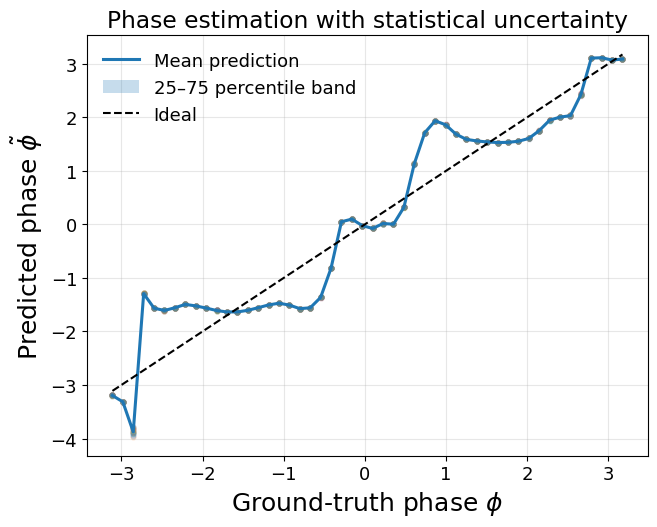

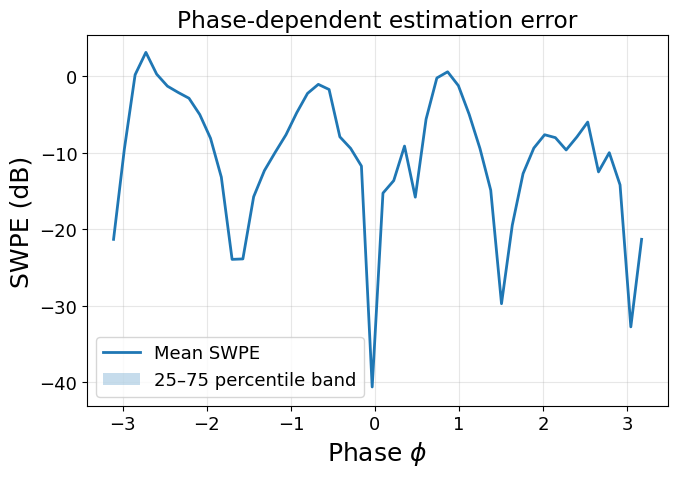

In [12]:

n_runs = 20
phi_preds_shots_all = []  # shape: [runs, phi_points]
for run in range(n_runs):
    phi_preds_shots = []
    for phi in phi_trues:
        probs = circuit_probs_shots(phi, q_params_fixed)
        p_m = probs_to_p_m(probs)
        v = net(p_m)
        phi_pred = pnp.arctan2(v[0], v[1])
        phi_preds_shots.append(float(qml.math.toarray(phi_pred)))

    phi_preds_shots = np.array(phi_preds_shots)
    # phase unwrap correction
    phi_preds_shots = adjust_phase_wrap(phi_trues, phi_preds_shots)
    phi_preds_shots_all.append(phi_preds_shots)


phi_preds_shots_all = np.array(phi_preds_shots_all)  # (runs, N)
np.save(os.path.join(path, "phi_preds_shots20.npy"), phi_preds_shots_all)

# =====================================================
# percentile band (NC preferred)
# =====================================================
phi_mean = np.median(phi_preds_shots_all, axis=0)
phi_lower = np.percentile(
    phi_preds_shots_all,
    25,
    axis=0
)
phi_upper = np.percentile(
    phi_preds_shots_all,
    75,
    axis=0
)

# =====================================================
# Plot: Predicted φ with percentile band
# =====================================================
plt.figure(figsize=(6.8, 5.5))

# main trend
plt.plot(
    phi_trues,
    phi_mean,
    linewidth=2.2,
    label="Mean prediction"
)

# percentile band
plt.fill_between(
    phi_trues,
    phi_lower,
    phi_upper,
    alpha=0.25,
    label="25–75 percentile band"
)

# ideal diagonal
plt.plot(
    phi_trues,
    phi_trues,
    '--',
    color='black',
    linewidth=1.5,
    label="Ideal"
)

# optional: show faint raw points
for run in range(phi_preds_shots_all.shape[0]):
    plt.scatter(
        phi_trues,
        phi_preds_shots_all[run],
        s=12,
        alpha=0.15
    )

plt.xlabel(r"Ground-truth phase $\phi$")
plt.ylabel(r"Predicted phase $\tilde{\phi}$")

plt.title("Phase estimation with statistical uncertainty")

plt.legend(frameon=False)
plt.grid(True, alpha=0.3)

plt.tight_layout()

plt.savefig(
    os.path.join(path, "phi_pred_percentile_band.png"),
    dpi=600
)

plt.savefig(
    os.path.join(path, "phi_pred_percentile_band.pdf"),
    bbox_inches='tight',
    dpi=600,
    format='pdf'
)

plt.show()


# =====================================================
# # SWPE with real uncertainty band（NC核心图）
# =====================================================
phase_error = np.angle(np.exp(1j * (phi_preds_shots_all - phi_trues))) ** 2
SWPE_dB_all = 10 * np.log10(phase_error + 1e-12)

SWPE_mean = np.median(SWPE_dB_all, axis=0)
SWPE_lower = np.percentile(
    SWPE_dB_all,
    25,
    axis=0
)
SWPE_upper = np.percentile(
    SWPE_dB_all,
    75,
    axis=0
)
plt.figure(figsize=(7,5))
plt.plot(
    phi_trues,
    SWPE_mean,
    linewidth=2,
    label="Mean SWPE"
)

plt.fill_between(
    phi_trues,
    SWPE_lower,
    SWPE_upper,
    alpha=0.25,
    label="25–75 percentile band"
)

plt.xlabel(r"Phase $\phi$")
plt.ylabel("SWPE (dB)")
plt.title("Phase-dependent estimation error")

plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(
    os.path.join(path, "SWPE_percentile_band.png"),
    dpi=600
)
plt.show()

In [5]:
import numpy as np

phi_list = phi_trues

def decoding_jacobian_stability(phi_true, phi_pred):
    """
    计算Jacobian的均值和方差
    """
    dphi = phi_true[1] - phi_true[0]
    J = np.gradient(phi_pred, dphi)
    
    J_mean = np.mean(J)
    J_var = np.var(J)
    
    return J_mean, J_var
    
phi_preds = []
for phi in phi_list:
    probs = circuit_probs(phi, q_params_fixed)
    p_m = probs_to_p_m(probs)
    v = net(p_m)                      # shape (2,)
    phi_pred = pnp.arctan2(v[0], v[1])
    phi_preds.append(float(qml.math.toarray(phi_pred)))

phi_preds = np.array(phi_preds)

# 修正角度跳变（±π跨越）
phi_preds = adjust_phase_wrap(phi_list, phi_preds)

J_mean, J_var = decoding_jacobian_stability(phi_list, phi_preds)

print("J_mean, J_var", J_mean, J_var)


J_mean, J_var 0.9722705988096294 5.038128241614586


In [6]:
import pickle

with open(os.path.join(path, "mlp_params.pkl"), "wb") as f:
    pickle.dump(best_x, f)

np.savez(
    os.path.join(path, "quantum_params.npz"),
    params=q_params_fixed
)



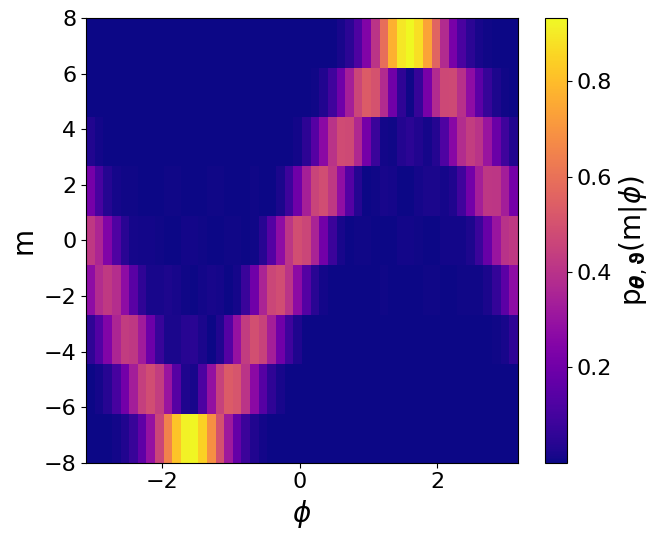

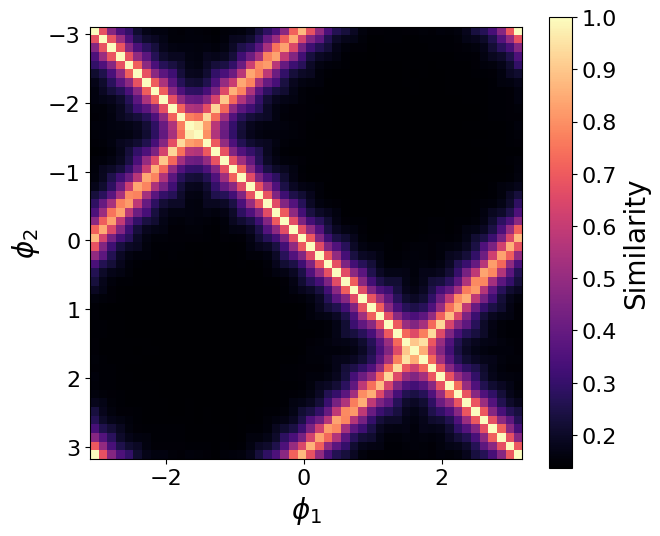

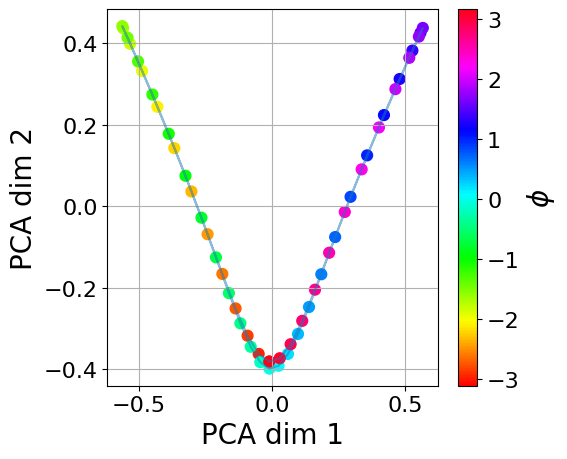

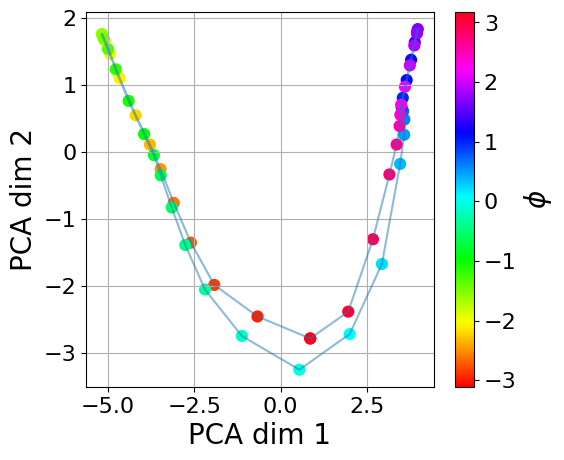

In [16]:
from sklearn.decomposition import PCA

act_func = "softsign"
path = f"VQ-CNNI_fixedParam/{n_qubits}/vqc_{n_enc}_{n_dec}/{act_func}/figs"

os.makedirs(path, exist_ok=True)

plt.rcParams.update({
    "font.size": 20,          # 全局字体大小
    "axes.labelsize": 20,     # 坐标轴标签
    "xtick.labelsize": 16,    # x轴刻度
    "ytick.labelsize": 16,    # y轴刻度
    "legend.fontsize": 20,
})

def circuit_probs_batch(phi_array, q_params):
    
    probs_list = []

    for phi in phi_array:
        probs_list.append(circuit_probs(phi, q_params))

    return np.array(probs_list)

# ============================================================
# 1 Quantum Feature Map
# ============================================================
# Compute measurement probability distribution
# p(m | φ)
# ============================================================

def compute_feature_map(phi_trues, q_params):

    probs_batch = circuit_probs_batch(phi_trues, q_params)

    p_m_matrix = np.array([
        probs_to_p_m(p) for p in probs_batch
    ])

    return p_m_matrix

# ============================================================
# 2 Phase Sensitivity
# ============================================================
# Numerical derivative
#
# ∂p(m|φ) / ∂φ
# ============================================================

def compute_sensitivity(phi_trues, q_params):

    dphi = 1e-5

    probs_p = circuit_probs_batch(phi_trues + dphi, q_params)
    probs_m = circuit_probs_batch(phi_trues - dphi, q_params)

    p_plus = np.array([probs_to_p_m(p) for p in probs_p])
    p_minus = np.array([probs_to_p_m(p) for p in probs_m])

    dp_dphi = (p_plus - p_minus) / (2 * dphi)

    return dp_dphi


# ============================================================
# 3 Fisher Information Density
# ============================================================
# Classical Fisher information
#
# I(φ) = Σ ( (∂p/∂φ)^2 / p )
# ============================================================

def compute_fisher_density(p_m_matrix, dp_dphi):

    eps = 1e-12

    I_phi = np.sum(
        (dp_dphi ** 2) / (p_m_matrix + eps),
        axis=1
    )

    return I_phi

# ============================================================
# 4 Phase Identifiability Matrix
# ============================================================
# Measure similarity between phase distributions
#
# S(φ1,φ2) = exp( - ||p(φ1) - p(φ2)|| )
# ============================================================

def compute_phase_identifiability(p_m_matrix):

    n_phi = p_m_matrix.shape[0]

    S = np.zeros((n_phi, n_phi))

    for i in range(n_phi):
        for j in range(n_phi):

            dist = np.sum(np.abs(p_m_matrix[i] - p_m_matrix[j]))

            S[i, j] = np.exp(-dist)

    return S

# ============================================================
# 5 Neural Network Latent Feature
# ============================================================
# Extract hidden-layer representation
# ============================================================

def compute_nn_latent(phi_trues, q_params):

    latent_list = []

    for phi in phi_trues:

        probs = circuit_probs(phi, q_params)
        p_m = probs_to_p_m(probs)

        h1 = softsign(net.W1 @ p_m + net.b1)
        h2 = softsign(net.W2 @ h1 + net.b2)

        latent_list.append(h2)

    return np.array(latent_list)

# ============================================================
# Fig1 Quantum Feature Map
# ============================================================

def plot_feature_map(phi_trues, p_m_matrix, unique_m, path):

    plt.figure(figsize=(7,5.8))

    plt.imshow(
        p_m_matrix.T,
        aspect='auto',
        extent=[phi_trues[0], phi_trues[-1], unique_m[0], unique_m[-1]],
        origin='lower',
        cmap="plasma"
    )

    plt.colorbar(label=r"p$_{\boldsymbol{\theta}, \boldsymbol{\vartheta}}$(m|$\phi$)")
    plt.xlabel(r'$\phi$')
    plt.ylabel("m")
    # plt.title("Quantum feature heatmap")

    plt.tight_layout()

    plt.savefig(f"{path}/Quantum_feature_heatmap.png", dpi=300)


# ============================================================
# Fig2 Quantum Feature Embedding
# ============================================================

def plot_feature_embedding(p_m_matrix, phi_trues, path):

    pca = PCA(n_components=2)

    feature_2d = pca.fit_transform(p_m_matrix)

    plt.figure(figsize=(6,5))

    sc = plt.scatter(
        feature_2d[:,0],
        feature_2d[:,1],
        c=phi_trues,
        cmap="hsv",
        s=60
    )

    plt.plot(feature_2d[:,0], feature_2d[:,1], alpha=0.5)

    plt.colorbar(sc,label=r'$\phi$')

    plt.xlabel("PCA dim 1")
    plt.ylabel("PCA dim 2")
    # plt.title("Quantum feature embedding")

    plt.grid(True)
    plt.tight_layout()

    plt.savefig(f"{path}/feature_embedding.png", dpi=300)


# ============================================================
# Fig5  NN Latent Manifold
# ============================================================

def plot_latent_manifold(phi_trues, q_params, path):

    latent_arr = compute_nn_latent(phi_trues, q_params)

    pca = PCA(n_components=2)

    latent_2d = pca.fit_transform(latent_arr)

    plt.figure(figsize=(6,5))

    sc = plt.scatter(
        latent_2d[:,0],
        latent_2d[:,1],
        c=phi_trues,
        cmap="hsv",
        s=60
    )

    plt.plot(latent_2d[:,0], latent_2d[:,1], alpha=0.5)

    plt.colorbar(sc,label=r'$\phi$')

    plt.xlabel("PCA dim 1")
    plt.ylabel("PCA dim 2")

    # plt.title("Latent feature manifold")

    plt.grid(True)
    plt.tight_layout()

    plt.savefig(f"{path}/fig5_latent_manifold.png", dpi=300)

    plt.show()

# ============================================================
# Fig6  Phase Identifiability Map
# ============================================================

def plot_phase_identifiability_map(p_m_matrix, phi_trues, path):

    S = compute_phase_identifiability(p_m_matrix)

    plt.figure(figsize=(7,5.8))

    plt.imshow(
        S,
        extent=[phi_trues[0],phi_trues[-1],phi_trues[-1],phi_trues[0]],
        cmap="magma"
    )

    plt.colorbar(label="Similarity")

    plt.xlabel(r'$\phi_{1}$')
    plt.ylabel(r'$\phi_{2}$')

    # plt.title("Phase identifiability map")

    plt.tight_layout()

    plt.savefig(f"{path}/fig6_phase_identifiability.png", dpi=300)

    plt.show()


# ============================================================
# Main Analysis
# ============================================================

p_m_matrix = compute_feature_map(phi_trues, q_params_fixed)

plot_feature_map(phi_trues, p_m_matrix, unique_m, path)

plot_phase_identifiability_map(p_m_matrix, phi_trues, path)

plot_feature_embedding(p_m_matrix, phi_trues, path)

plot_latent_manifold(phi_trues, q_params_fixed, path)

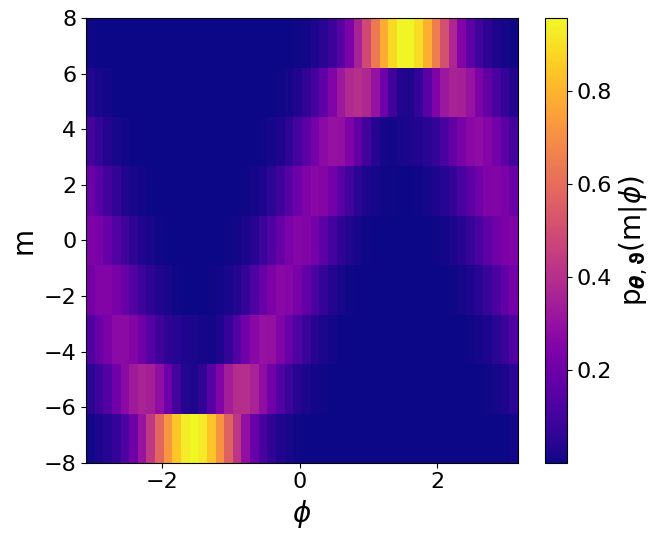

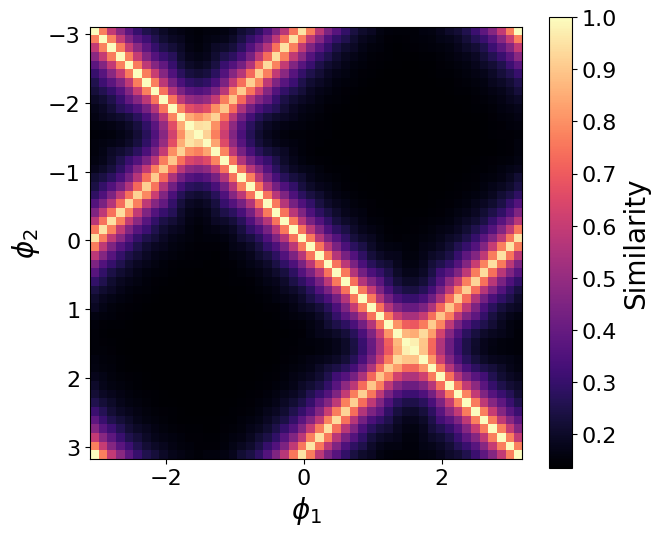

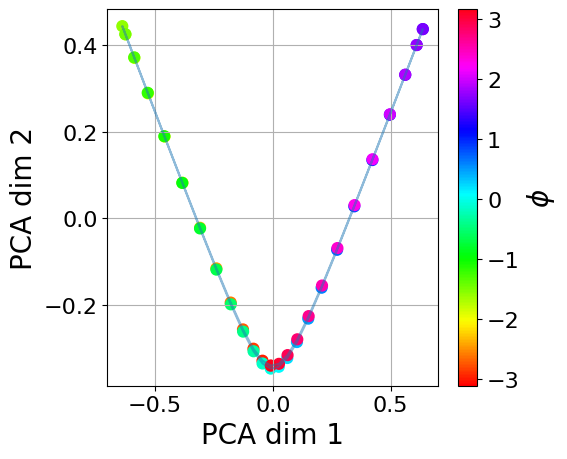

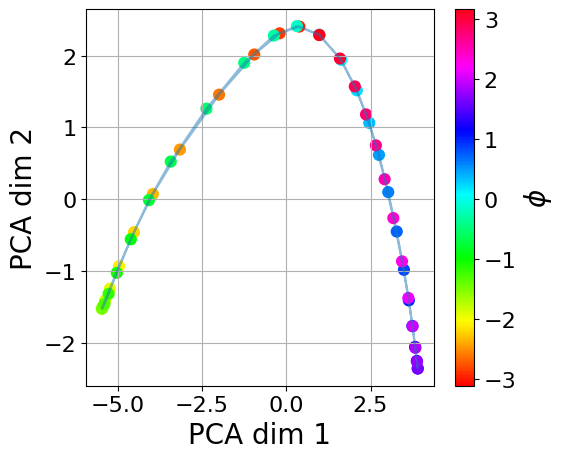

In [17]:

theta_init = np.random.uniform(-0.1, 0.1, 3 * n_enc) if n_enc > 0 else np.array([])
curly_init = np.random.uniform(-0.1, 0.1, 3 * n_dec) if n_dec > 0 else np.array([])
q_params_init = pnp.concatenate([theta_init, curly_init])

path = f"VQ-CNNI_fixedParam/{n_qubits}/vqc_{n_enc}_{n_dec}/{act_func}/figs_init"

os.makedirs(path, exist_ok=True)


# ============================================================
# Main Analysis
# ============================================================

p_m_matrix = compute_feature_map(phi_trues, q_params_init)

plot_feature_map(phi_trues, p_m_matrix, unique_m, path)

plot_phase_identifiability_map(p_m_matrix, phi_trues, path)

plot_feature_embedding(p_m_matrix, phi_trues, path)

plot_latent_manifold(phi_trues, q_params_init, path)


In [11]:
path = path.split("/figs_init")[0]

def compute_QFI(phi, x, dphi=1e-5):
    """中心差分计算纯态下的QFI"""
    # 计算phi+dphi, phi-dphi的态向量
    psi_plus = circuit_state(phi + dphi, x)
    psi_minus = circuit_state(phi - dphi, x)

    # 中心差分导数
    dpsi = (psi_plus - psi_minus)/(2*dphi)
    psi0 = (psi_plus + psi_minus)/2

    # --- QFI: 纯态公式 ---
    F_q = 4*(np.vdot(dpsi,dpsi).real - np.abs(np.vdot(psi0,dpsi))**2)

    return float(F_q)

QFI = compute_QFI(0.0, q_params_fixed)
print(f"QFI: {QFI:.4f}")
np.save(os.path.join(path, "QFI.npy"), np.array([QFI]))


QFI: 17.3553
